# Train TimeSformer MAE for Threshold Typology Learning

This notebook trains a Masked Autoencoder (MAE) with **asymmetric masking**:
- Frames 0-1 (before): 90% masked
- Frames 2-4 (at threshold): 50% masked (context)
- Frames 5-6 (after): 90% masked

**Goal**: Learn representations by reconstructing heavily-masked before/after frames using threshold context.

## Setup

In [14]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from config_mae import get_mae_config
from timesformer_mae import TimeSformerMAE
from dataset_mae import create_mae_dataloaders
from masking import unpatchify

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0.dev20251029+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## Configuration

In [15]:
# Data path
DATA_ROOT = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data"

# Training hyperparameters
NUM_EPOCHS = 30
BATCH_SIZE = 32
NUM_WORKERS = 4
TRAIN_SPLIT = 0.85

# Resume training
RESUME_FROM = '../models_MAE/output_mae_adjusted2/checkpoints/checkpoint_epoch_25.pt'    # '../models_MAE/output_mae/checkpoints/checkpoint_epoch_40.pt'

# Output
OUTPUT_DIR = '../models_MAE/output_mae_adjusted2'
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
VIS_DIR = os.path.join(OUTPUT_DIR, 'visualizations')
SAVE_EVERY = 5

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Epochs: 30
  Batch size: 32
  Output: ../models_MAE/output_mae_adjusted2


## Create Model

In [16]:
# Get config
config = get_mae_config()

# Create MAE model
model = TimeSformerMAE(config)
model = model.to(device)

print(f"\nModel parameters:")
total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder_blocks.parameters())
decoder_params = sum(p.numel() for p in model.decoder_blocks.parameters())
print(f"  Total: {total_params:,}")
print(f"  Encoder: {encoder_params:,}")
print(f"  Decoder: {decoder_params:,}")

MAE Configuration:
  Image: 32×64, 1 channel(s)
  Patch size: 8×8
  Patches per frame: 32 (4×8)
  Total frames: 7
  Total patches: 224
  Masking strategy: ASYMMETRIC
    Frames 0-1 (before): 90% masked
    Frames 2-4 (at threshold): 50% masked
    Frames 5-6 (after): 90% masked
  Average mask ratio: 72.9%
  Encoder: 6 layers, dim=384
  Decoder: 4 layers, dim=192

Model parameters:
  Total: 12,596,800
  Encoder: 10,646,784
  Decoder: 1,779,456


## Create Data Loaders

In [17]:
train_loader, val_loader, full_dataset, train_indices, val_indices = create_mae_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
)

print(f"Data loaded:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

Found 32 CSV files
Loaded 8046 threshold sequences from 32 files

Dataset split:
  Train samples: 6839
  Val samples: 1207

Data loaded:
  Train batches: 213
  Val batches: 38


## Setup Optimizer

In [18]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.95)
)

# Learning rate scheduler with warmup
def lr_lambda(epoch):
    if epoch < config.warmup_epochs:
        return (epoch + 1) / config.warmup_epochs
    else:
        # Cosine decay after warmup
        progress = (epoch - config.warmup_epochs) / (config.max_epochs - config.warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Training state
start_epoch = 0
train_losses = []
val_losses = []
best_val_loss = float('inf')

if RESUME_FROM is not None:
    print(f"Loading checkpoint from: {RESUME_FROM}")
    checkpoint = torch.load(RESUME_FROM, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    if 'train_losses' in checkpoint:
        train_losses = checkpoint['train_losses']
    if 'val_losses' in checkpoint:
        val_losses = checkpoint['val_losses']
    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']
    for _ in range(start_epoch):
        scheduler.step()
    print(f"Resuming from epoch {start_epoch}")
else:
    print("Starting fresh training")

print(f"Optimizer: AdamW (lr={config.learning_rate}, wd={config.weight_decay})")
print(f"Scheduler: Warmup {config.warmup_epochs} epochs + Cosine decay")

Loading checkpoint from: ../models_MAE/output_mae_adjusted2/checkpoints/checkpoint_epoch_25.pt
Resuming from epoch 25
Optimizer: AdamW (lr=0.00015, wd=0.05)
Scheduler: Warmup 10 epochs + Cosine decay


C:\Users\shrua\AppData\Local\Temp\ipykernel_32552\3864017978.py:39: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


## Training Loop

In [ ]:
print("="*80)
print("TRAINING")
print("="*80)
print()

for epoch in range(start_epoch, NUM_EPOCHS):
    # ============ Training ============
    model.train()
    train_loss_epoch = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        imgs = batch['frames'].to(device)  # [B, 7, 1, 32, 64]
        
        # Forward pass with asymmetric masking
        loss, pred, mask = model(imgs, config.frame_mask_ratios)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_epoch += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss_epoch /= len(train_loader)
    train_losses.append(train_loss_epoch)
    
    # ============ Validation ============
    model.eval()
    val_loss_epoch = 0.0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
        for batch in pbar:
            imgs = batch['frames'].to(device)
            loss, pred, mask = model(imgs, config.frame_mask_ratios)
            val_loss_epoch += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    val_loss_epoch /= len(val_loader)
    val_losses.append(val_loss_epoch)
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train Loss: {train_loss_epoch:.4f}")
    print(f"  Val Loss:   {val_loss_epoch:.4f}")
    print(f"  LR:         {current_lr:.2e}")
    
    # Save best model
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'config': config,
        }, os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
        print(f"  → Best model saved! (val_loss: {val_loss_epoch:.4f})")
    
    # Save periodic checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'config': config,
        }, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pt'))
        print(f"  → Checkpoint saved (epoch {epoch+1})")
    
    print()

print("="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"Best validation loss: {best_val_loss:.4f}")

# Save final model
torch.save({
    'epoch': NUM_EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
    'config': config,
}, os.path.join(CHECKPOINT_DIR, 'final_model.pt'))

# Save encoder only
encoder_state = {}
for k, v in model.state_dict().items():
    if k.startswith('encoder') or k.startswith('patch_embed') or 'emb' in k:
        encoder_state[k] = v
torch.save(encoder_state, os.path.join(OUTPUT_DIR, 'encoder_mae_pretrained.pt'))
print(f"Encoder saved to: {os.path.join(OUTPUT_DIR, 'encoder_mae_pretrained.pt')}")

TRAINING



Epoch 11/30 [Train]:   0%|          | 0/213 [00:09<?, ?it/s]

Epoch 11/30 [Val]:   0%|          | 0/38 [00:23<?, ?it/s]

Epoch 11/30:
  Train Loss: 0.3557
  Val Loss:   0.3191
  LR:         1.50e-04
  → Best model saved! (val_loss: 0.3191)



Epoch 12/30 [Train]:   0%|          | 0/213 [00:25<?, ?it/s]

...

Epoch 27/30:
  Train Loss: 0.1359
  Val Loss:   0.1162
  LR:         1.47e-04
  → Best model saved! (val_loss: 0.1162)



Epoch 28/30 [Train]:   0%|          | 0/213 [00:15<?, ?it/s]

Epoch 28/30 [Val]:   0%|          | 0/38 [00:21<?, ?it/s]

Epoch 28/30:
  Train Loss: 0.1321
  Val Loss:   0.1118
  LR:         1.47e-04
  → Best model saved! (val_loss: 0.1118)



Epoch 29/30 [Train]:   0%|          | 0/213 [00:22<?, ?it/s]

## Visualize Training Curves

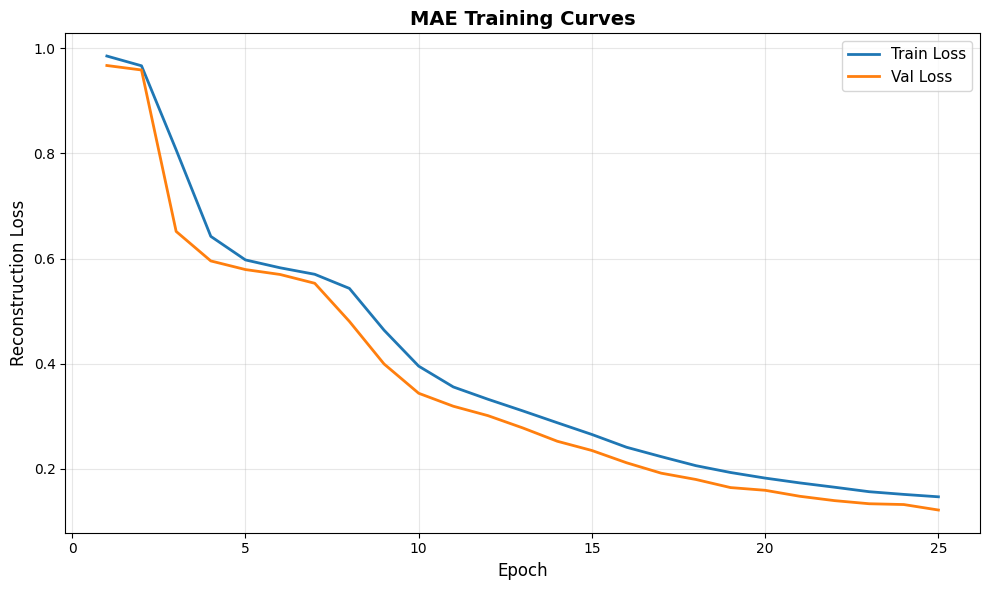

Training curves saved to: ../models_MAE/output_mae_adjusted2\training_curves.png


In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

epochs = np.arange(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label='Train Loss', linewidth=2)
ax.plot(epochs, val_losses, label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Reconstruction Loss', fontsize=12)
ax.set_title('MAE Training Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")

## Visualize Reconstructions

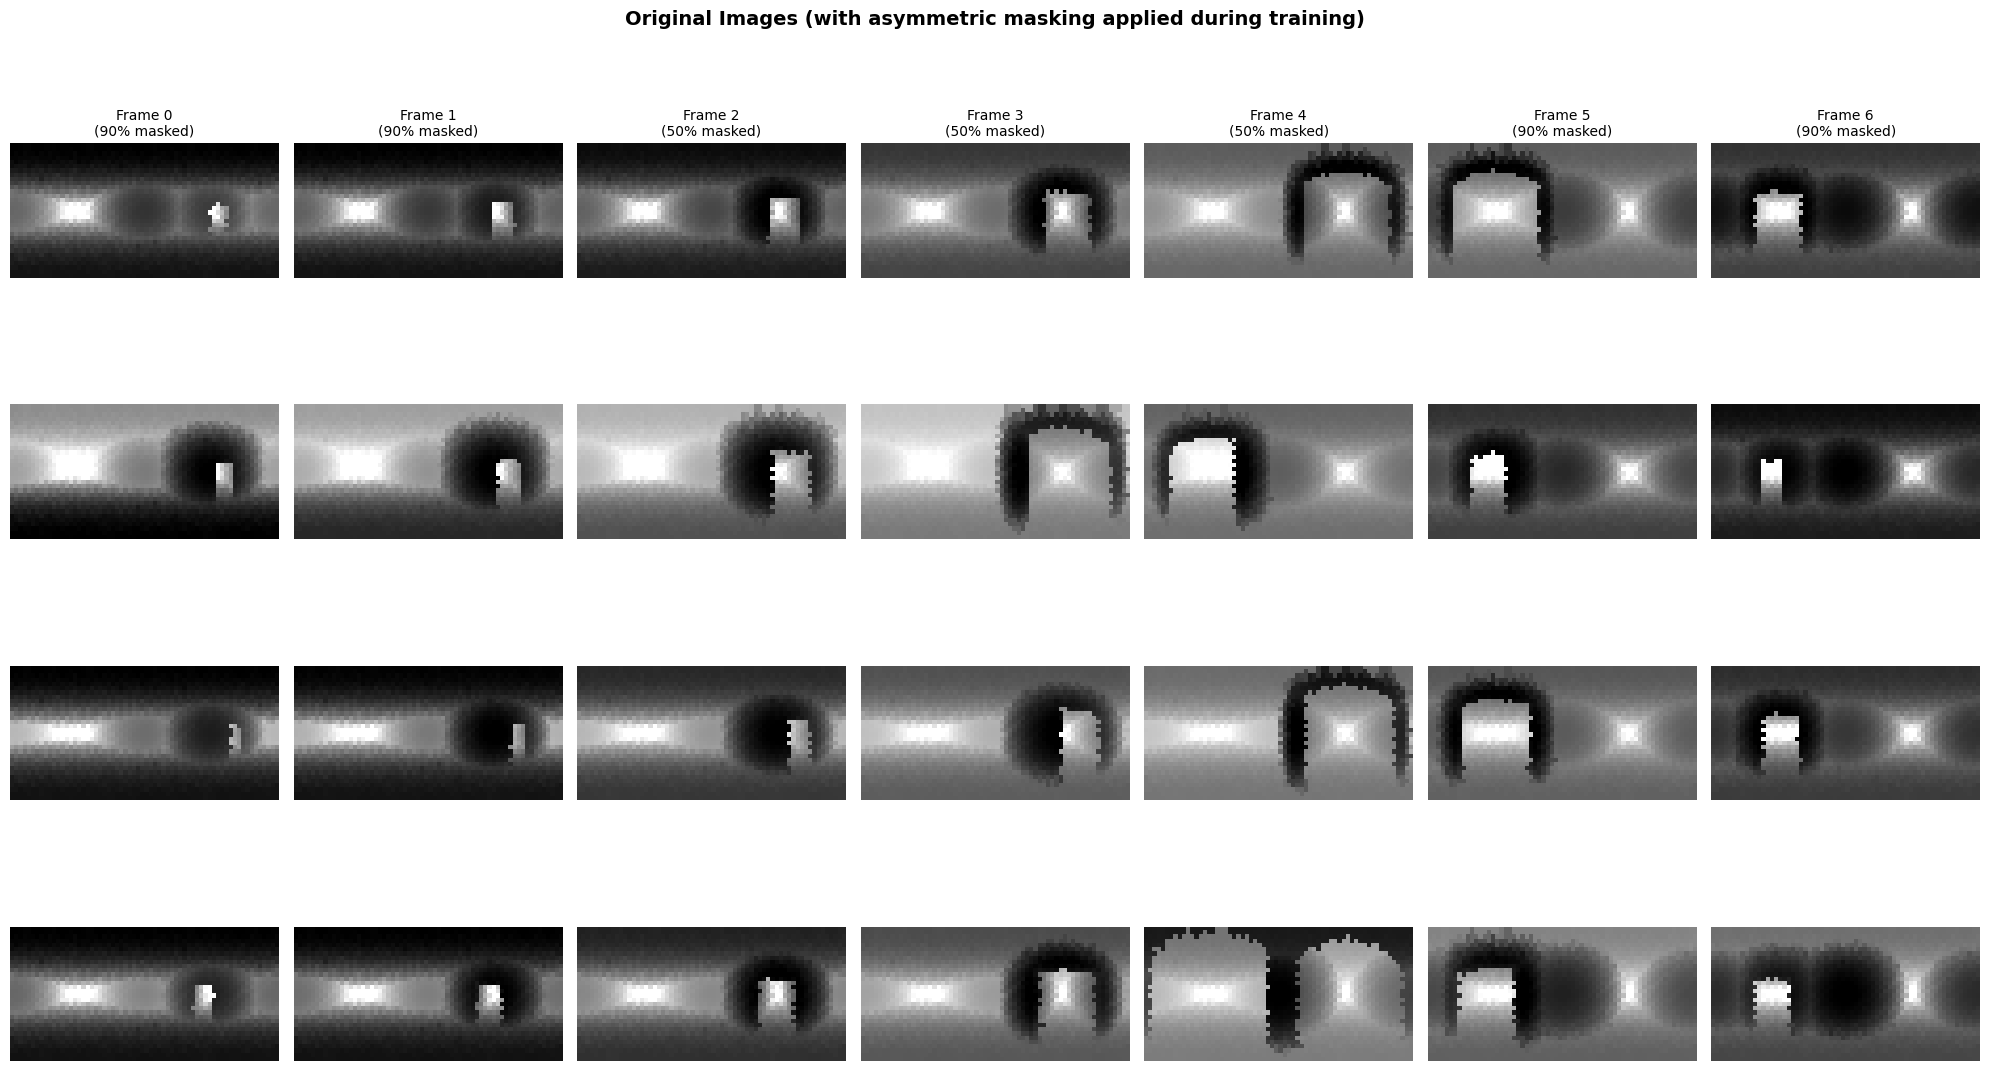

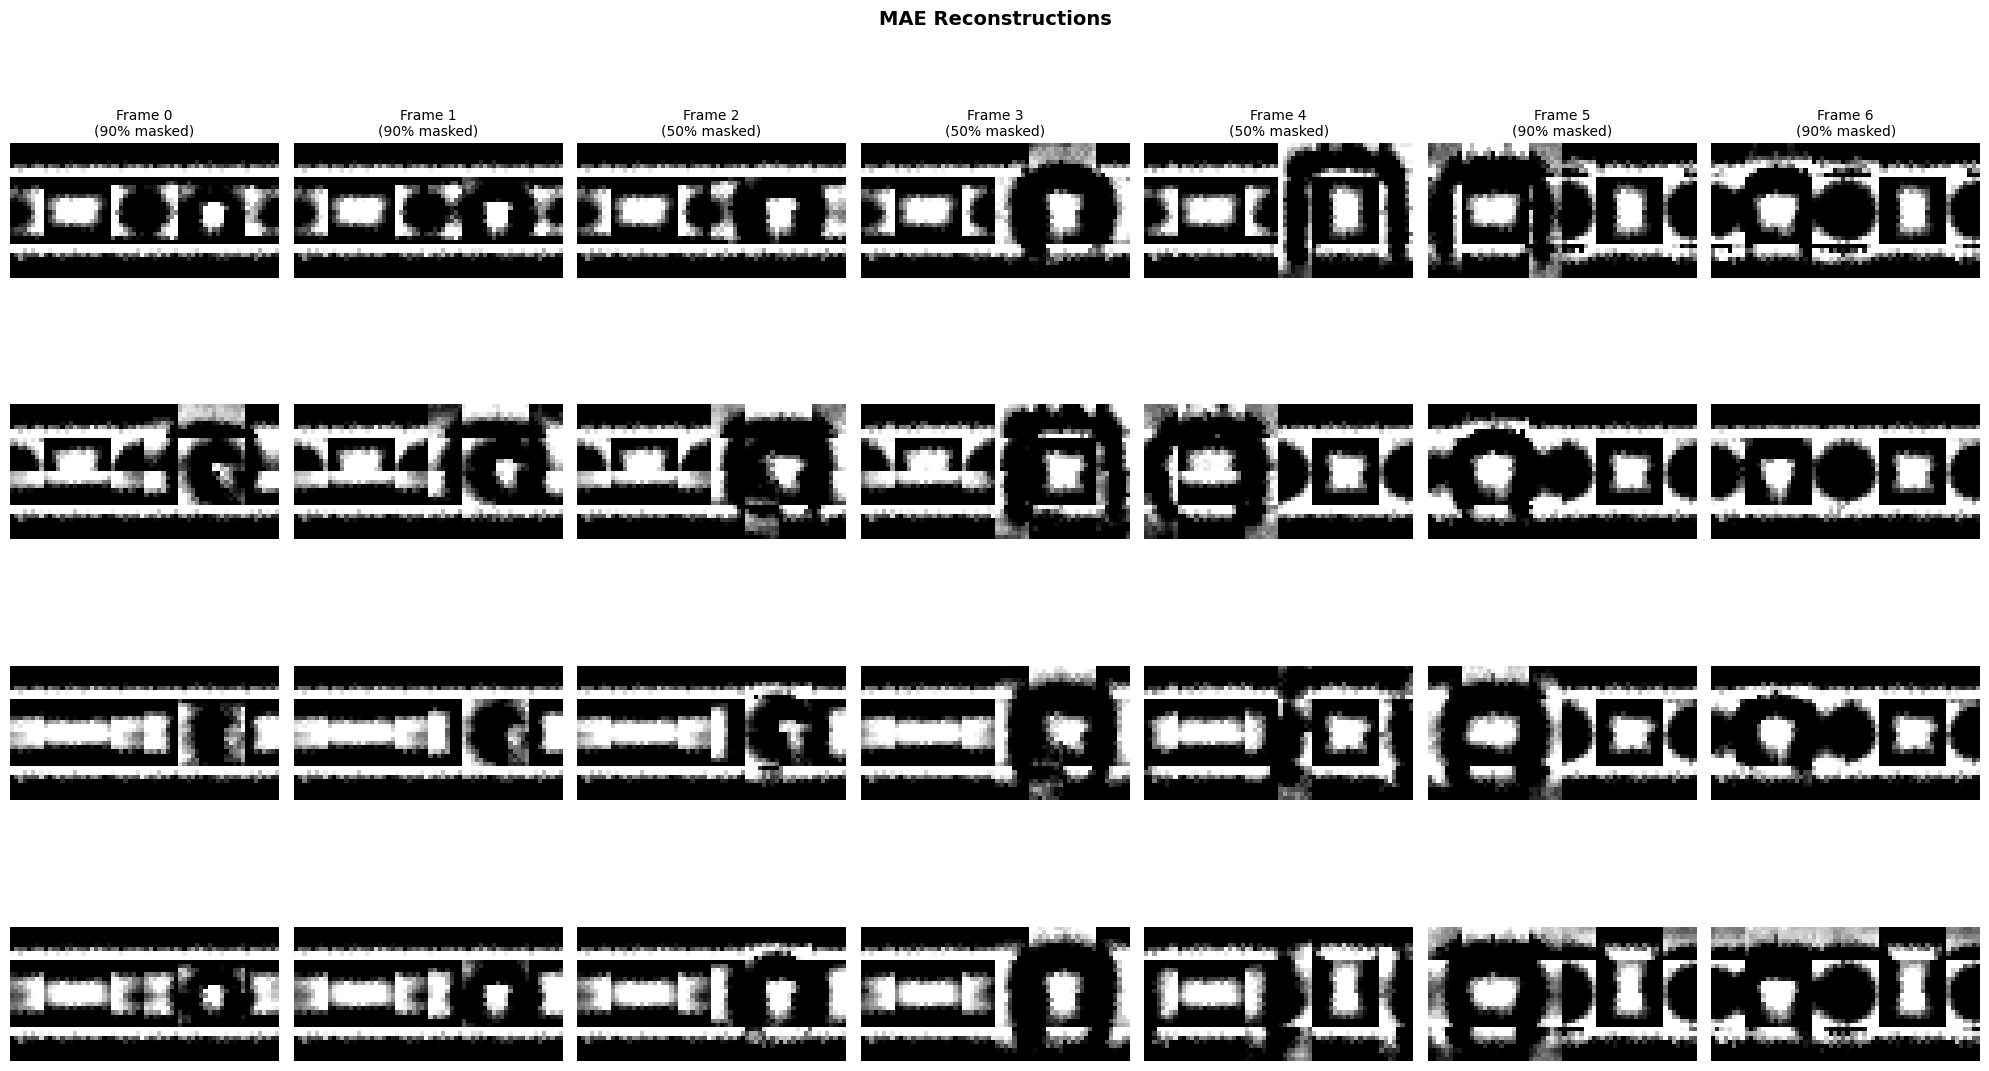

Reconstruction visualizations saved to ../models_MAE/output_mae_adjusted2\visualizations


In [21]:
# Load best model
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Get a validation batch
batch = next(iter(val_loader))
imgs = batch['frames'][:4].to(device)  # Take 4 samples

# Forward pass
with torch.no_grad():
    loss, pred, mask = model(imgs, config.frame_mask_ratios)

# Reconstruct images
pred_imgs = unpatchify(
    pred, config.patch_size, config.num_frames, config.num_channels,
    config.image_height, config.image_width
)

# Visualize
fig, axes = plt.subplots(4, 7, figsize=(20, 12))

for i in range(4):
    for t in range(7):
        # Original
        axes[i, t].imshow(imgs[i, t, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i, t].axis('off')
        
        # Show mask info
        mask_ratio = config.frame_mask_ratios[t]
        if i == 0:
            axes[i, t].set_title(f'Frame {t}\n({mask_ratio:.0%} masked)', fontsize=10)

plt.suptitle('Original Images (with asymmetric masking applied during training)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'reconstruction_originals.png'), dpi=150)
plt.show()

# Reconstructions
fig, axes = plt.subplots(4, 7, figsize=(20, 12))

for i in range(4):
    for t in range(7):
        # Reconstruction
        axes[i, t].imshow(pred_imgs[i, t, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i, t].axis('off')
        
        mask_ratio = config.frame_mask_ratios[t]
        if i == 0:
            axes[i, t].set_title(f'Frame {t}\n({mask_ratio:.0%} masked)', fontsize=10)

plt.suptitle('MAE Reconstructions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'reconstruction_predictions.png'), dpi=150)
plt.show()

print(f"Reconstruction visualizations saved to {VIS_DIR}")

## TSNE

In [22]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

print("="*80)
print("EXTRACTING MAE EMBEDDINGS")
print("="*80)
print()

# Load best model
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model (epoch {}, val_loss: {:.4f})".format(
    checkpoint['epoch'], checkpoint['val_loss']))
print()

# Extract embeddings from validation set (no masking!)
embeddings = []
labels = []
typology_names_list = []

print("Extracting embeddings from validation set...")
with torch.no_grad():
    for idx in tqdm(val_indices):
        sample = full_dataset[idx]
        frames = sample['frames'].unsqueeze(0).to(device)  # (1, 7, 1, 32, 64)
        
        # Run encoder WITHOUT masking (pass all zeros for mask ratios)
        x_encoded, _, _ = model.forward_encoder(frames, frame_mask_ratios=(0,0,0,0,0,0,0))
        
        # Global average pooling over all tokens
        h = x_encoded.mean(dim=1)  # (1, 384)
        
        embeddings.append(h.cpu().numpy())
        labels.append(sample['typology_label'])
        typology_names_list.append(sample['metadata']['typology'].split('-')[0])

embeddings = np.concatenate(embeddings, axis=0)  # (N, 384)
labels = np.array(labels)  # (N,)

print(f"\nExtracted {len(embeddings)} embeddings")
print(f"Embedding shape: {embeddings.shape}")
print()

# Analyze typology distribution
print("="*80)
print("TYPOLOGY DISTRIBUTION IN VALIDATION SET")
print("="*80)
unique_labels = np.unique(labels)
unique_typologies = sorted(set(typology_names_list))
print(f"Number of unique typologies: {len(unique_labels)}")
print(f"Unique typology names: {unique_typologies}")
print()

print("Sample counts per typology:")
for typology in unique_typologies:
    count = sum(1 for t in typology_names_list if t == typology)
    sample_idx = typology_names_list.index(typology)
    label_idx = labels[sample_idx]
    print(f"  {typology} (label {label_idx}): {count} samples")
print()

if len(unique_labels) < 8:
    print(f"⚠ WARNING: Only {len(unique_labels)} typologies in validation set!")
else:
    print("✓ All 8 typologies present in validation set")
print()
print("="*80)

EXTRACTING MAE EMBEDDINGS

Loaded best model (epoch 27, val_loss: 0.1118)

Extracting embeddings from validation set...


  0%|          | 0/1207 [00:00<?, ?it/s]


Extracted 1207 embeddings
Embedding shape: (1207, 384)

TYPOLOGY DISTRIBUTION IN VALIDATION SET
Number of unique typologies: 8
Unique typology names: ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']

Sample counts per typology:
  t1 (label 0): 154 samples
  t2 (label 1): 151 samples
  t3 (label 2): 161 samples
  t4 (label 3): 127 samples
  t5 (label 4): 148 samples
  t6 (label 5): 158 samples
  t7 (label 6): 172 samples
  t8 (label 7): 136 samples

✓ All 8 typologies present in validation set



In [23]:
# Compute t-SNE
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) // 4))
embeddings_2d = tsne.fit_transform(embeddings)
print("t-SNE complete")
print()

# Compute clustering metrics
num_clusters = len(unique_labels)
silhouette = silhouette_score(embeddings, labels)

# K-means clustering
print(f"Running K-means with {num_clusters} clusters...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(embeddings)
ari = adjusted_rand_score(labels, pred_labels)

print("="*80)
print("CLUSTERING METRICS")
print("="*80)
print(f"Number of typologies: {num_clusters}")
print(f"Silhouette Score: {silhouette:.3f} (range: -1 to 1, higher is better)")
print(f"Adjusted Rand Index (ARI): {ari:.3f} (range: 0 to 1, higher is better)")
print()

# Interpret results
print("Silhouette Score interpretation:")
if silhouette > 0.3:
    print("  ✓ EXCELLENT! Silhouette > 0.3 indicates good clustering!")
elif silhouette > 0.1:
    print("  ✓ GOOD! Silhouette > 0.1 shows some clustering structure.")
elif silhouette > 0:
    print("  ~ MARGINAL. Silhouette > 0 but weak clustering.")
else:
    print("  ✗ POOR. Negative silhouette indicates random/overlapping clusters.")
print()

print("ARI interpretation:")
if ari > 0.5:
    print("  ✓ EXCELLENT! ARI > 0.5 indicates strong agreement with typologies!")
elif ari > 0.3:
    print("  ✓ GOOD! ARI > 0.3 shows reasonable clustering.")
elif ari > 0.1:
    print("  ~ MARGINAL. ARI > 0.1 but weak agreement.")
else:
    print("  ✗ POOR. ARI near 0 indicates no clustering structure.")

print("="*80)

Computing t-SNE (this may take a minute)...
t-SNE complete

Running K-means with 8 clusters...
CLUSTERING METRICS
Number of typologies: 8
Silhouette Score: 0.157 (range: -1 to 1, higher is better)
Adjusted Rand Index (ARI): 0.348 (range: 0 to 1, higher is better)

Silhouette Score interpretation:
  ✓ GOOD! Silhouette > 0.1 shows some clustering structure.

ARI interpretation:
  ✓ GOOD! ARI > 0.3 shows reasonable clustering.


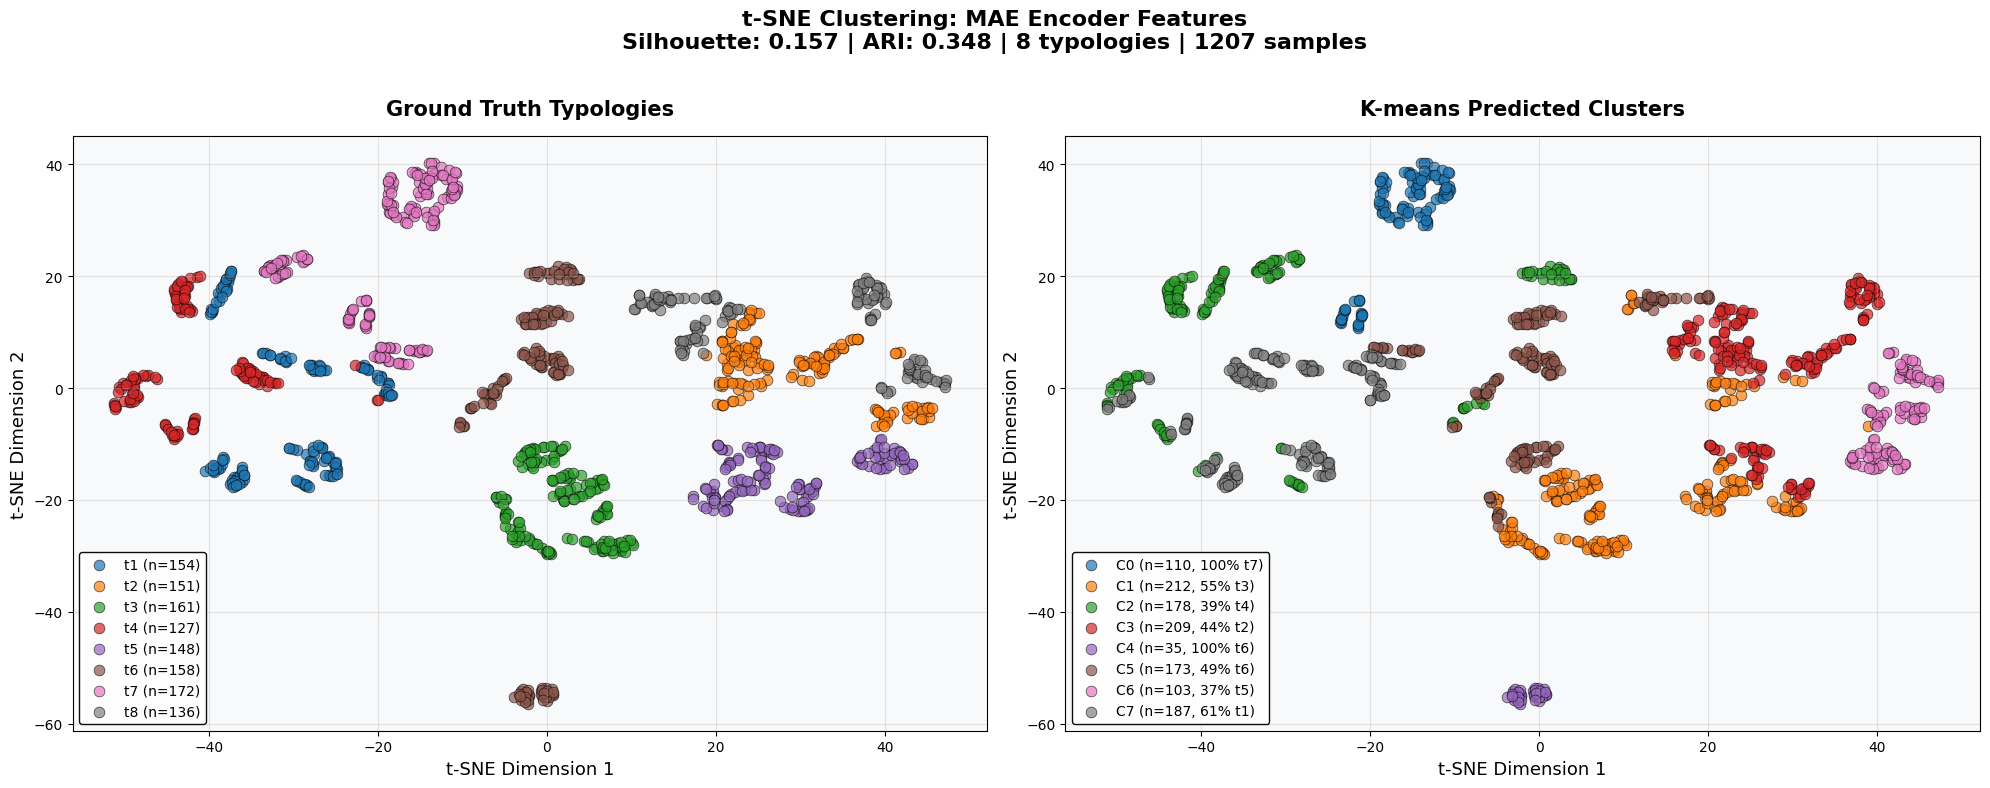


t-SNE plot saved to: ../models_MAE/output_mae_adjusted2\tsne_clustering_mae.png

VISUALIZATION GUIDE
LEFT PLOT (Ground Truth):
  - Each color = one typology (t1, t2, ...)
  - Points close together = similar MAE embeddings
  - If MAE learned well, same typology should cluster together

RIGHT PLOT (K-means Predictions):
  - Each color = one predicted cluster
  - Percentage shows cluster purity (% of dominant typology)
  - High purity + good separation = good MAE learning

Silhouette = 0.157:
  → MAE learned some typology structure.

ARI = 0.348:
  → Moderate agreement. Some clustering structure learned.


In [24]:
# Visualize t-SNE: Ground Truth vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Create color map
if num_clusters <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, 10))[:num_clusters]
else:
    colors = plt.cm.tab20(np.linspace(0, 1, 20))[:num_clusters]

# Create mapping from label to typology name
label_to_name = {}
for i, label in enumerate(labels):
    if label not in label_to_name:
        label_to_name[label] = typology_names_list[i]

# LEFT PLOT: Ground Truth Labels
ax = axes[0]
for i, label_idx in enumerate(unique_labels):
    mask = labels == label_idx
    typology_name = label_to_name[label_idx]
    count = np.sum(mask)
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=f'{typology_name} (n={count})',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'Ground Truth Typologies',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# RIGHT PLOT: Predicted Clusters (K-means)
ax = axes[1]
unique_pred_labels = np.unique(pred_labels)
for i, pred_label_idx in enumerate(unique_pred_labels):
    mask = pred_labels == pred_label_idx
    count = np.sum(mask)
    # Find which ground truth typology is most common in this cluster
    gt_labels_in_cluster = labels[mask]
    most_common_gt = np.bincount(gt_labels_in_cluster).argmax()
    most_common_name = label_to_name[most_common_gt]
    purity = np.sum(gt_labels_in_cluster == most_common_gt) / len(gt_labels_in_cluster) * 100
    
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i % len(colors)]],
        label=f'C{pred_label_idx} (n={count}, {purity:.0f}% {most_common_name})',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'K-means Predicted Clusters',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# Overall title with metrics
fig.suptitle(
    f't-SNE Clustering: MAE Encoder Features\n' + 
    f'Silhouette: {silhouette:.3f} | ARI: {ari:.3f} | {num_clusters} typologies | {len(embeddings)} samples',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clustering_mae.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nt-SNE plot saved to: {os.path.join(OUTPUT_DIR, 'tsne_clustering_mae.png')}")
print()
print("="*80)
print("VISUALIZATION GUIDE")
print("="*80)
print("LEFT PLOT (Ground Truth):")
print("  - Each color = one typology (t1, t2, ...)")
print("  - Points close together = similar MAE embeddings")
print("  - If MAE learned well, same typology should cluster together")
print()
print("RIGHT PLOT (K-means Predictions):")
print("  - Each color = one predicted cluster")
print("  - Percentage shows cluster purity (% of dominant typology)")
print("  - High purity + good separation = good MAE learning")
print()
print(f"Silhouette = {silhouette:.3f}:")
if silhouette > 0.3:
    print("  → MAE learned excellent typology-distinguishing features!")
elif silhouette > 0.1:
    print("  → MAE learned some typology structure.")
else:
    print("  → MAE struggled to learn typology distinctions.")
print()
print(f"ARI = {ari:.3f}:")
if ari > 0.5:
    print("  → Strong agreement! Predicted clusters match typologies well.")
elif ari > 0.3:
    print("  → Moderate agreement. Some clustering structure learned.")
else:
    print("  → Weak agreement. Clusters don't align with typologies.")
print("="*80)

## Summary

In [25]:
print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print()
print(f"Model: TimeSformer MAE with Asymmetric Masking")
print(f"Epochs trained: {len(train_losses)}")
print(f"Best val loss: {best_val_loss:.4f}")
print()
print("Masking strategy:")
print(f"  Frames 0-1 (before): {config.frame_mask_ratios[0]:.0%} masked")
print(f"  Frames 2-4 (at threshold): {config.frame_mask_ratios[2]:.0%} masked")
print(f"  Frames 5-6 (after): {config.frame_mask_ratios[5]:.0%} masked")
print()
print("Output files:")
print(f"  Best model: {os.path.join(CHECKPOINT_DIR, 'best_model.pt')}")
print(f"  Encoder: {os.path.join(OUTPUT_DIR, 'encoder_mae_pretrained.pt')}")
print(f"  Training curves: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")
print()
print("Next steps:")
print("  1. Fine-tune encoder on classification task")
print("  2. Compare with SimCLR approach")
print("  3. Evaluate t-SNE clustering of MAE features")
print("="*80)

TRAINING SUMMARY

Model: TimeSformer MAE with Asymmetric Masking
Epochs trained: 25
Best val loss: 0.1216

Masking strategy:
  Frames 0-1 (before): 90% masked
  Frames 2-4 (at threshold): 50% masked
  Frames 5-6 (after): 90% masked

Output files:
  Best model: ../models_MAE/output_mae_adjusted2\checkpoints\best_model.pt
  Encoder: ../models_MAE/output_mae_adjusted2\encoder_mae_pretrained.pt
  Training curves: ../models_MAE/output_mae_adjusted2\training_curves.png

Next steps:
  1. Fine-tune encoder on classification task
  2. Compare with SimCLR approach
  3. Evaluate t-SNE clustering of MAE features
